In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


In [2]:
# ==========================================
# 1. CARREGAMENTO E TRATAMENTO DE DADOS
# ==========================================
print("Iniciando carregamento e tratamento...")

df_reviews = pd.read_csv('olist_order_reviews_dataset.csv')
df_orders = pd.read_csv('olist_orders_dataset.csv')
df_items = pd.read_csv('olist_order_items_dataset.csv')

df = pd.merge(df_reviews, df_orders, on='order_id', how='inner')

df_items_sum = df_items.groupby('order_id').agg({
    'price': 'sum', 
    'freight_value': 'sum'
}).reset_index()

df = pd.merge(df, df_items_sum, on='order_id', how='left')

date_cols = ['order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date']
for col in date_cols:
    df[col] = pd.to_datetime(df[col])

df['delivery_days'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days
df['delay_days'] = df['delivery_days'] - (df['order_estimated_delivery_date'] - df['order_purchase_timestamp']).dt.days


Iniciando carregamento e tratamento...


In [3]:
# ==========================================
# 2. IA NLP: ANÁLISE DE TÓPICOS (LDA)
# ==========================================
print("Executando IA NLP (LDA)...")
df_low_score = df[(df['review_score'] <= 2) & (df['review_comment_message'].notnull())].copy()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', '', text)
    return text

df_low_score['cleaned_msg'] = df_low_score['review_comment_message'].apply(clean_text)
pt_stop = ['a', 'o', 'que', 'do', 'da', 'de', 'em', 'um', 'para', 'com', 'na', 'no', 'uma', 'os', 'as', 'não', 'mais', 'meu', 'produto', 'recebi', 'veio', 'entrega', 'ainda', 'compra', 'pois', 'foi', 'pelo', 'ser']

vectorizer = CountVectorizer(max_df=0.9, min_df=5, stop_words=pt_stop)
tf = vectorizer.fit_transform(df_low_score['cleaned_msg'])

lda = LatentDirichletAllocation(n_components=3, random_state=42)
lda.fit(tf)

Executando IA NLP (LDA)...


,"n_components n_components: int, default=10Number of topics... versionchanged:: 0.19 ``n_topics`` was renamed to ``n_components``",3
,"doc_topic_prior doc_topic_prior: float, default=NonePrior of document topic distribution `theta`. If the value is None,defaults to `1 / n_components`.In [1]_, this is called `alpha`.",None
,"topic_word_prior topic_word_prior: float, default=NonePrior of topic word distribution `beta`. If the value is None, defaultsto `1 / n_components`.In [1]_, this is called `eta`.",None
,"learning_method learning_method: {'batch', 'online'}, default='batch'Method used to update `_component`. Only used in :meth:`fit` method.In general, if the data size is large, the online update will be muchfaster than the batch update.Valid options:- 'batch': Batch variational Bayes method. Use all training data in each EM update. Old `components_` will be overwritten in each iteration.- 'online': Online variational Bayes method. In each EM update, use mini-batch of training data to update the ``components_`` variable incrementally. The learning rate is controlled by the ``learning_decay`` and the ``learning_offset`` parameters... versionchanged:: 0.20 The default learning method is now ``""batch""``.",'batch'
,"learning_decay learning_decay: float, default=0.7It is a parameter that control learning rate in the online learningmethod. The value should be set between (0.5, 1.0] to guaranteeasymptotic convergence. When the value is 0.0 and batch_size is``n_samples``, the update method is same as batch learning. In theliterature, this is called kappa.",0.7
,"learning_offset learning_offset: float, default=10.0A (positive) parameter that downweights early iterations in onlinelearning. It should be greater than 1.0. In the literature, this iscalled tau_0.",10.0
,"max_iter max_iter: int, default=10The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the :meth:`fit` method, and not the:meth:`partial_fit` method.",10
,"batch_size batch_size: int, default=128Number of documents to use in each EM iteration. Only used in onlinelearning.",128
,"evaluate_every evaluate_every: int, default=-1How often to evaluate perplexity. Only used in `fit` method.set it to 0 or negative number to not evaluate perplexity intraining at all. Evaluating perplexity can help you check convergencein training process, but it will also increase total training time.Evaluating perplexity in every iteration might increase training timeup to two-fold.",-1
,"total_samples total_samples: int, default=1e6Total number of documents. Only used in the :meth:`partial_fit` method.",1000000.0
,"perp_tol perp_tol: float, default=1e-1Perplexity tolerance. Only used when ``evaluate_every`` is greater than 0.",0.1


In [4]:
# ==========================================
# 3. IA CLUSTERING: SEGMENTAÇÃO (K-MEANS)
# ==========================================
print("Executando IA de Clustering...")
cols_cluster = ['price', 'freight_value', 'delivery_days', 'review_score']
df_cluster = df.dropna(subset=cols_cluster).copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster[cols_cluster])

# Cálculo da Inércia (apenas uma vez para otimizar)
inertia = []
K_range = range(1, 8)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_cluster['cluster'] = kmeans.fit_predict(X_scaled)

Executando IA de Clustering...


Gerando gráficos...


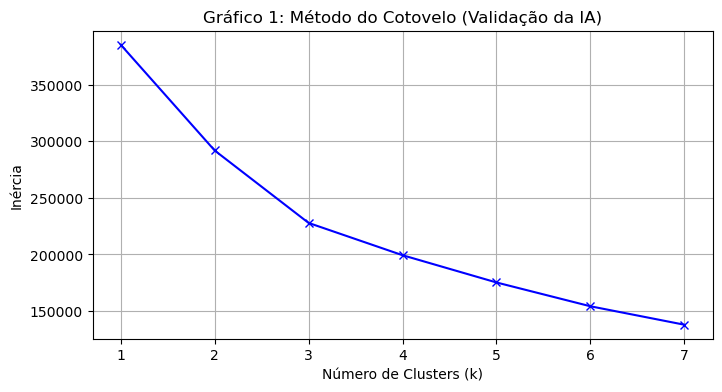

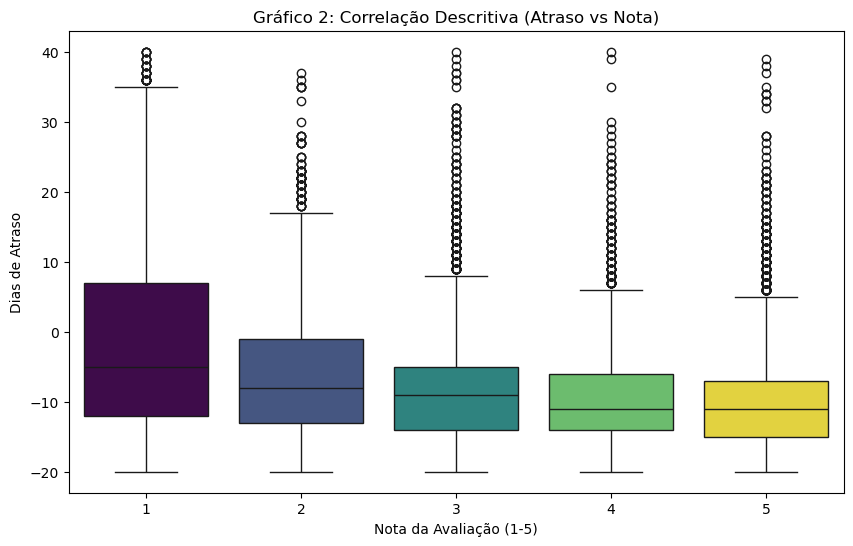

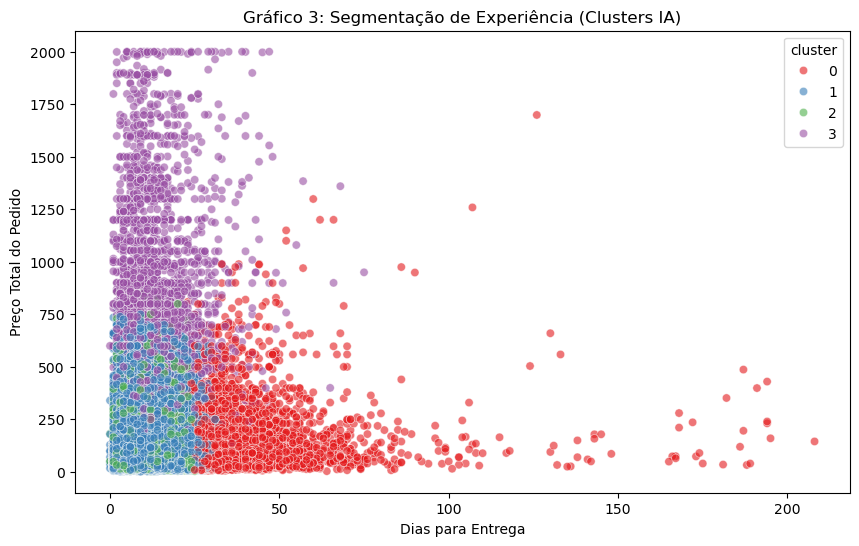

In [5]:
# ==========================================
# 4. GERAÇÃO DE GRÁFICOS (TODOS EXIBIDOS)
# ==========================================
print("Gerando gráficos...")

# GRÁFICO 1: Método do Cotovelo
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, 'bx-')
plt.title('Gráfico 1: Método do Cotovelo (Validação da IA)')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inércia')
plt.grid(True)
plt.savefig('elbow_method.png')
plt.show() # <--- Adicionado para aparecer nos resultados

# GRÁFICO 2: Atraso vs Nota
plt.figure(figsize=(10, 6))
sns.boxplot(
    x='review_score', 
    y='delay_days', 
    data=df[df['delay_days'].between(-20, 40)], 
    hue='review_score',
    palette='viridis', 
    legend=False
)
plt.title('Gráfico 2: Correlação Descritiva (Atraso vs Nota)')
plt.xlabel('Nota da Avaliação (1-5)')
plt.ylabel('Dias de Atraso')
plt.savefig('analise_atraso_nota.png')
plt.show()

# GRÁFICO 3: Visualização dos Clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='delivery_days', 
    y='price', 
    hue='cluster', 
    data=df_cluster[df_cluster['price'] < 2000], 
    palette='Set1', 
    alpha=0.6
)
plt.title('Gráfico 3: Segmentação de Experiência (Clusters IA)')
plt.xlabel('Dias para Entrega')
plt.ylabel('Preço Total do Pedido')
plt.savefig('clusters_segmentacao.png')
plt.show() # <--- Adicionado para aparecer nos resultados


In [7]:

# EXIBIÇÃO DE RESULTADOS NO TERMINAL
print("\n" + "="*40)
print("TOPICOS DE RECLAMAÇÃO (IA NLP):")
words = vectorizer.get_feature_names_out()
for idx, topic in enumerate(lda.components_):
    print(f"Grupo {idx+1}: {[words[i] for i in topic.argsort()[:-6:-1]]}")

print("\nRESUMO DOS CLUSTERS (PERFIS OPERACIONAIS):")
print(df_cluster.groupby('cluster')[cols_cluster].mean())
print("="*40)

df_cluster.to_csv('resultado_final_olist_ia.csv', index=False)



TOPICOS DE RECLAMAÇÃO (IA NLP):
Grupo 1: ['nao', 'eu', 'me', 'comprei', 'por']
Grupo 2: ['até', 'prazo', 'entregue', 'dia', 'já']
Grupo 3: ['comprei', 'muito', 'mas', 'chegou', 'qualidade']

RESUMO DOS CLUSTERS (PERFIS OPERACIONAIS):
              price  freight_value  delivery_days  review_score
cluster                                                        
0        135.209384      27.015335      37.222771      2.095303
1        107.296408      19.478179      10.091134      4.756207
2        113.001957      21.704349      11.246673      2.062614
3        797.207439      83.312690      13.589572      4.124064
